In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [74]:
class value:
    def __init__(self,value, _children=(), _op='', label=''):
        self.data = value
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __add__(self,other):
        return value(self.data + other.data, _children=(self, other), _op='+')
    
    def __mul__(self,other):
        return value(self.data * other.data, _children=(self, other), _op='*')
    
    def __repr__(self):
        return f"value({self.data})"

In [70]:
a = value(10, label='a')
b = value(2, label='b')
c = value(5, label='c')
d = a * b
d.label = 'd'
e = c + d
e.label = 'e'
f = value(3, label='f')
g = e * f
g.label = 'g'

In [71]:
g._prev

{value(25), value(3)}

In [72]:
g._op

'*'

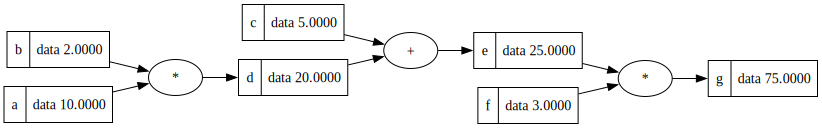

In [73]:
draw_dot(g)